In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.shape

(891, 15)

In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
df["age"]=df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df.drop(columns="deck", inplace=True)

In [9]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [10]:
df.duplicated().sum()

np.int64(116)

In [11]:
df.drop_duplicates(inplace=True)

<Axes: xlabel='survived', ylabel='count'>

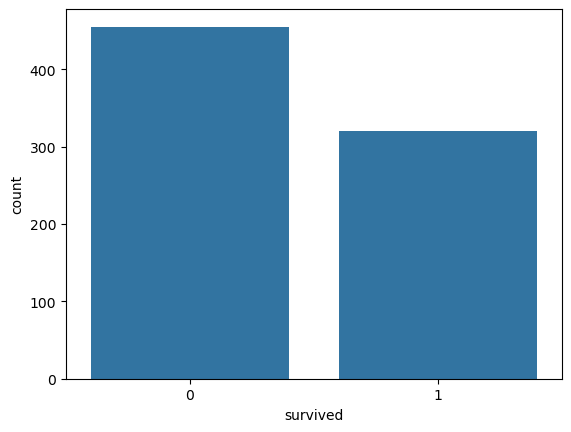

In [12]:
sns.countplot(x="survived", data=df)

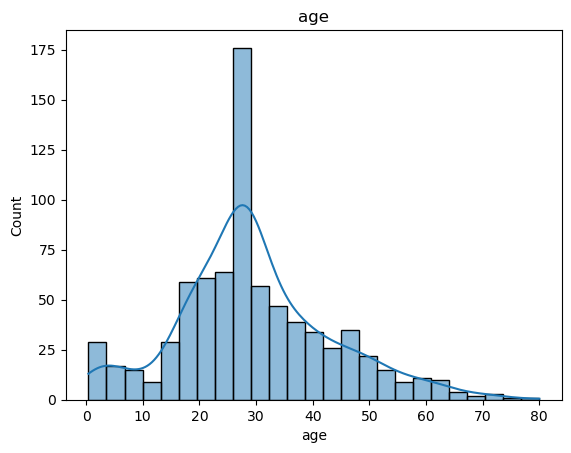

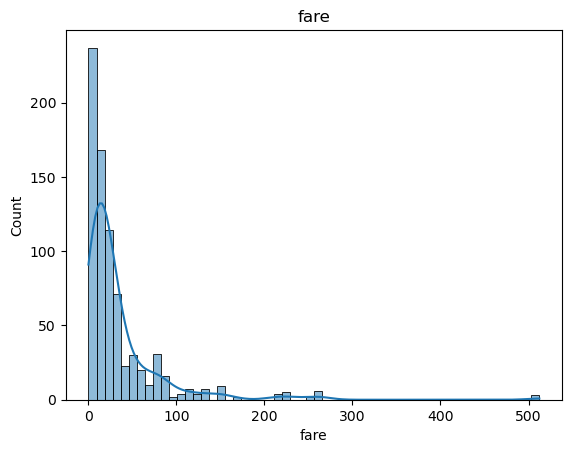

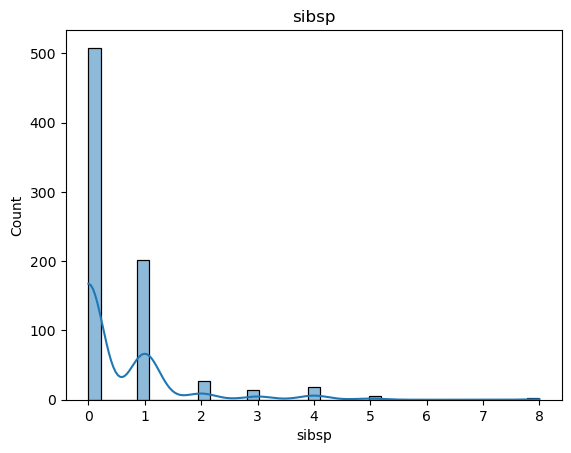

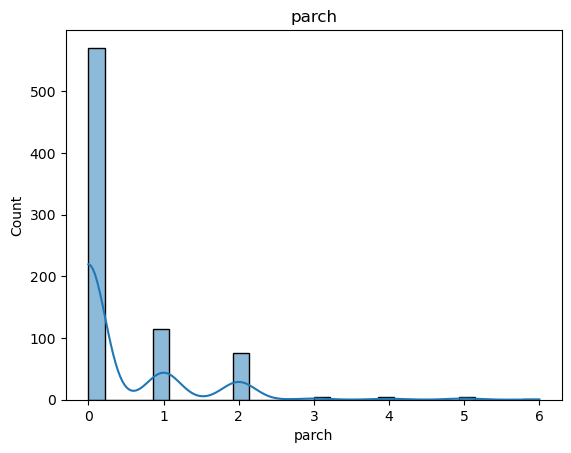

In [13]:
num_cols = ["age","fare","sibsp","parch"]

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

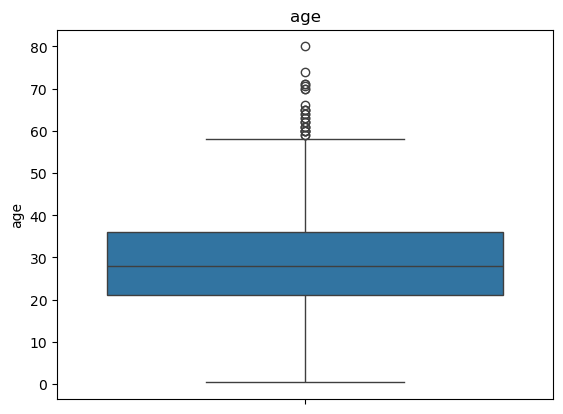

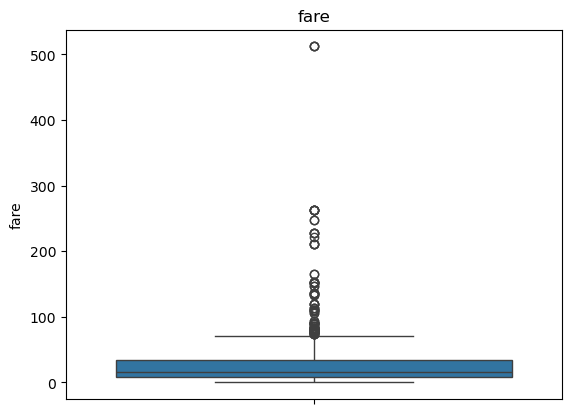

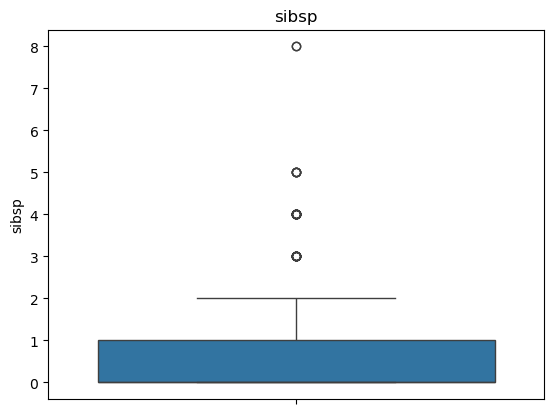

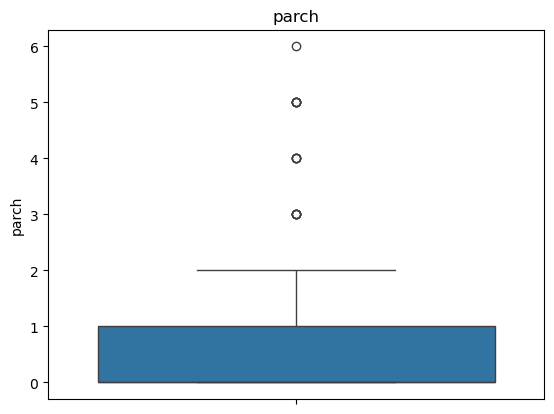

In [14]:
for col in num_cols:
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

<Axes: >

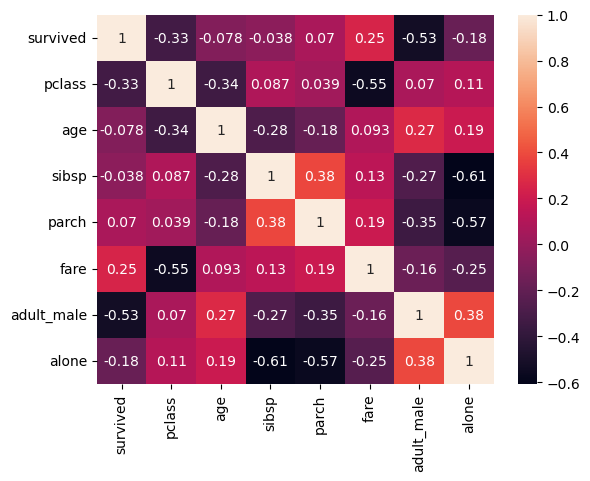

In [15]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

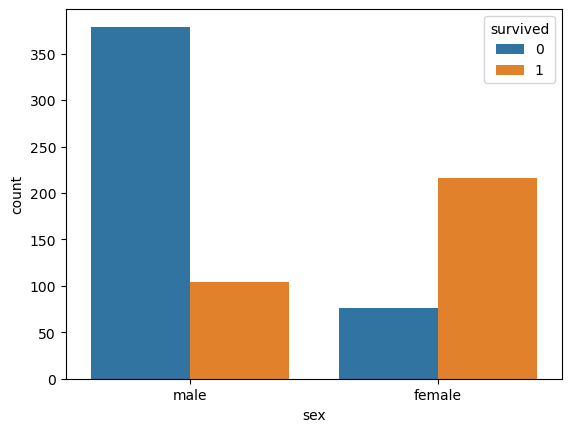

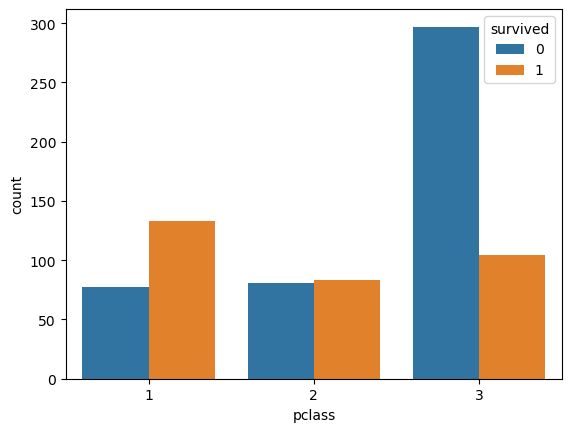

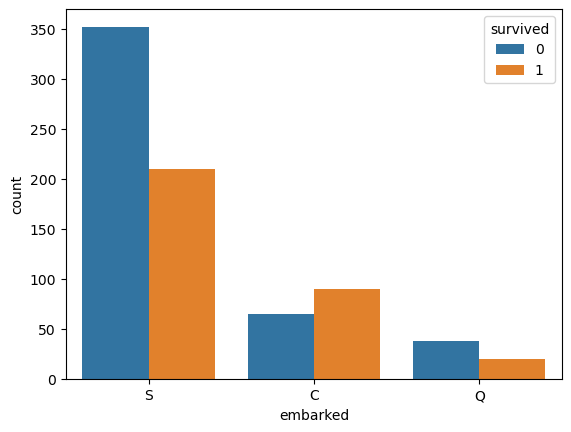

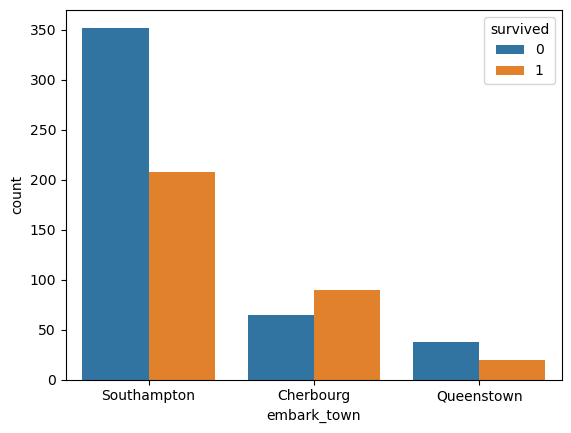

In [16]:
cat_cols = ["sex","pclass","embarked","embark_town"]

for col in cat_cols:
    sns.countplot(x=col,hue="survived",data=df)
    plt.show()

In [17]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [18]:
df.drop(
    columns=[
        "class",
        "who",
        "adult_male",
        "embark_town",
        "alive",
        "alone"
    ],
    inplace=True
)

In [19]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='object')

In [20]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [21]:
df = pd.get_dummies(
    df,
    columns=["sex","embarked"],
    drop_first=True
)

In [22]:
X = df.drop("survived",axis=1)

y = df["survived"]

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [26]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
y_pred = model.predict(X_test)

In [28]:
y_prob = model.predict_proba(X_test)[:,1]

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [30]:
print("Accuracy :",accuracy_score(y_test,y_pred))

print("Precision :",precision_score(y_test,y_pred))

print("Recall :",recall_score(y_test,y_pred))

print("F1 Score :",f1_score(y_test,y_pred))

print("ROC-AUC :",roc_auc_score(y_test,y_prob))

Accuracy : 0.7677419354838709
Precision : 0.7
Recall : 0.7
F1 Score : 0.7
ROC-AUC : 0.851578947368421


In [31]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81        95
           1       0.70      0.70      0.70        60

    accuracy                           0.77       155
   macro avg       0.76      0.76      0.76       155
weighted avg       0.77      0.77      0.77       155



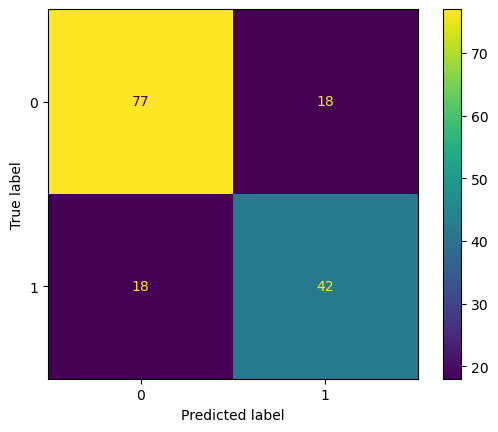

In [32]:
cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot()

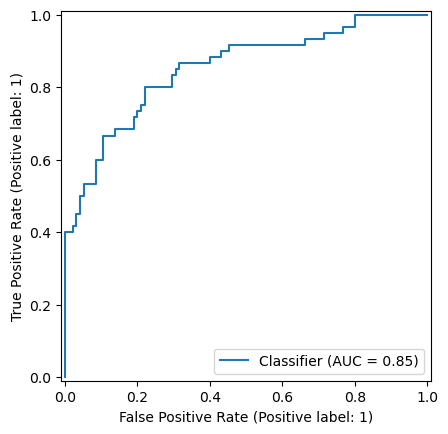

In [33]:
RocCurveDisplay.from_predictions(y_test,y_prob)

In [34]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
})

coef.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

,Feature,Coefficient
5,sex_male,-1.119629
0,pclass,-0.916807
1,age,-0.552714
2,sibsp,-0.403844
7,embarked_S,-0.205048
6,embarked_Q,-0.145782
4,fare,0.067060
3,parch,-0.048104


In [35]:
from sklearn.neighbors import KNeighborsClassifier

In [77]:
knn_model=KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train,y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [78]:
y_pred_knn=knn_model.predict(X_test)

In [79]:
print("Accuracy :",accuracy_score(y_test,y_pred_knn))

print("Precision :",precision_score(y_test,y_pred_knn))

print("Recall :",recall_score(y_test,y_pred_knn))

print("F1 Score :",f1_score(y_test,y_pred_knn))

Accuracy : 0.8129032258064516
Precision : 0.7924528301886793
Recall : 0.7
F1 Score : 0.7433628318584071


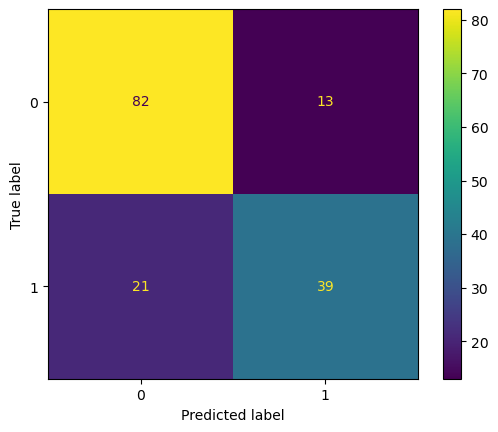

In [40]:
cm = confusion_matrix(y_test,y_pred_knn)
ConfusionMatrixDisplay(cm).plot()

In [80]:
from sklearn.naive_bayes import GaussianNB

In [81]:
nb_model=GaussianNB()
nb_model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [82]:
y_pred_nb=nb_model.predict(X_test)

In [84]:
print("Accuracy :",accuracy_score(y_test,y_pred_nb))

print("Precision :",precision_score(y_test,y_pred_nb))

print("Recall :",recall_score(y_test,y_pred_nb))

print("F1 Score :",f1_score(y_test,y_pred_nb))

Accuracy : 0.7806451612903226
Precision : 0.7166666666666667
Recall : 0.7166666666666667
F1 Score : 0.7166666666666667


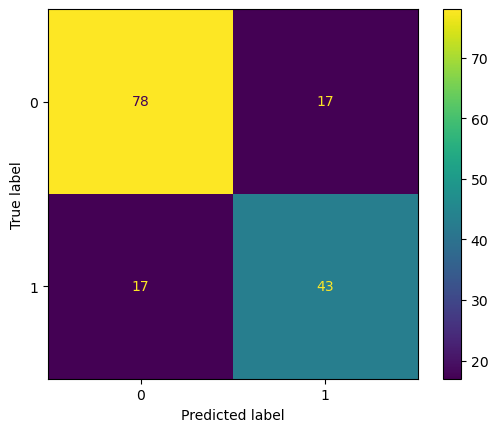

In [85]:
cm = confusion_matrix(y_test,y_pred_nb)
ConfusionMatrixDisplay(cm).plot()